In [1]:
import pandas as pd
from pathlib import Path
from functions import vote_functions

Plusieurs jeux de données sont mobilisés ci-dessous : 
- les résultats des élections municipales
- les listes des municipales, pour récupérer les couleurs politiques de tous les élus municipaux pour les interco
- la liste des présidents d'interco, pour donner une couleur politique aux interco
- la correspondance entre EPCI et communes appartenant à l'interco
- la correspondance entre code Insee et code postal

### Importation données listes municipales 2014

In [2]:
# Dossier contenant uniquement les fichiers à importer
dossier_listes_2014 = Path("/home/onyxia/work/projet3A/data/donnees_electorales/listes_muni_2014")

# Liste de tous les fichiers du dossier
fichiers_2014 = dossier_listes_2014.iterdir()

dfs = []

for f in fichiers_2014:
    ligne_header = vote_functions.detecter_ligne_header(f)
    df = pd.read_excel(f, header=ligne_header)
    df["source"] = f.name  # optionnelle
    dfs.append(df)

df_listes_muni_2014 = pd.concat(dfs, ignore_index=True)

print("Dimensions :", df_listes_muni_2014.shape)

Dimensions : (520074, 16)


On garde uniquement les infos sur la ville, la liste et le numéro dans la liste de chaque personne sur une liste municipale

In [3]:
df_listes_muni_2014.drop(labels = [ "Critère d'export", 'Libellé du département','Libellé commune', 'N° Panneau Liste', 'Code Dépôt',
       'Libellé abrégé liste', 'Libellé Etendu Liste',
       'Sexe', 'Nationalité',
       'Candidat au conseil communautaire', 'source'],axis = 1, inplace=True)

Importation du jeu de données contenant les résultats de toutes les élections (sauf municipales de 2014 qui sont manquantes)

In [5]:
import importlib
import boto3
import os 
from dotenv import load_dotenv
from functions import s3_connexion
from pathlib import Path

# Si le .env est à la racine, remonter d'un niveau (IMPORTANT !!!! ADAPTER selon l'arborescence)
#on met autant de .parent qu'il faut remonter 
dotenv_path = Path().resolve().parent.parent / ".env"
load_dotenv(dotenv_path=dotenv_path, override=True)
s3 = s3_connexion.get_s3()

remote_path = "Elections/candidats_results.txt"
local_path = f"/tmp/{os.path.basename(remote_path)}"    
s3.download_file("mgarbe", remote_path, local_path)
all_elections=pd.read_csv(local_path, sep=";")
all_elections.loc[22340396, 'Binôme'] = all_elections.loc[22160435, 'Binôme']

/tmp/ipykernel_18268/2716464246.py:17: DtypeWarning: Columns (0: Code du département, 1: Code du b.vote, 2: Libellé Abrégé Liste, 3: Libellé Etendu Liste, 4: Nom Tête de Liste, 5: Sexe, 6: Nom, 7: Prénom, 8: Nuance, 9: Binôme, 10: Liste) have mixed types. Specify dtype option on import or set low_memory=False.
  all_elections=pd.read_csv(local_path, sep=";")


In [146]:
muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",
    encoding="latin-1", skiprows=17, header= None)
muni_2014.columns = ['id_tour', 'Code du département', 'Code de la commune', 'Nom de la commune',
'Code du b.vote', 'Inscrits', 'Votants', 'Exprimes', 'num liste', 'Nom', 'Prénom', 'Nuance', 'Voix']
muni_2014['id_tour'] = "t" + muni_2014['id_tour'].astype(str)
print(muni_2014.shape)
print('Nb de communes dans le df', muni_2014['Nom de la commune'].nunique())


#On supprime tous les candidats de liste sans nuance politique !!! 
muni_2014 = muni_2014[muni_2014['Nuance'] != "NC"]
print(muni_2014.shape)
print('Nb de communes dans le df', muni_2014['Nom de la commune'].nunique())

/tmp/ipykernel_18268/2821078893.py:1: DtypeWarning: Columns (0: 1, 1: 4) have mixed types. Specify dtype option on import or set low_memory=False.
  muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",


(692029, 13)
Nb de communes dans le df 34221
(206898, 13)
Nb de communes dans le df 9613


In [ ]:
muni_2014.head()

,id_tour,Code du département,Code de la commune,Nom de la commune,Code du b.vote,Inscrits,Votants,Exprimes,num liste,Nom,Prénom,Nuance,Voix
27,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,3,PIDOUX,Catherine,LDVG,92
28,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,5,FORTIN,Christophe,LUMP,164
29,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,4,FABRE,Daniel,LDVD,169
30,t1,1,4,Ambérieu-en-Bugey,0001,1011,565,539,2,EXPOSITO,Josiane,LDVG,114
31,t1,1,4,Ambérieu-en-Bugey,0002,1104,660,638,5,FORTIN,Christophe,LUMP,190


## Etape initiale : constituer une liste des nuances de tous les candidats

##### Traitement des données des candidats aux départementales, qui ont un format "binome"

In [17]:
elec_binome = all_elections[all_elections["Binôme"].notna()]
liste_elec_binome = elec_binome['id_election'].unique()
election_dep = all_elections[all_elections['id_election'].isin(liste_elec_binome)]
election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)
election_dep = election_dep[["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"]]
election_dep[["candidat1", "candidat2"]] = election_dep["Binôme"].str.split(" et ", expand=True)

# Enlever les titres "M" ou "Mme" au début
election_dep["candidat1"] = election_dep["candidat1"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)
election_dep["candidat2"] = election_dep["candidat2"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)

election_dep[[ "nom1", "prenom1"]] = election_dep["candidat1"].str.split(" ", n=1, expand=True)
election_dep["prenom1"] = election_dep["prenom1"].str.lower()
election_dep[[ "nom2","prenom2"]] = election_dep["candidat2"].str.split(" ", n=1, expand=True)
election_dep["prenom2"] = election_dep["prenom2"].str.lower()

election_dep_long = pd.wide_to_long(election_dep, 
                          stubnames=["prenom", "nom"], 
                          i=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], 
                          j="num_binôme",   # nouveau suffixe qui indiquera 1 ou 2
                          sep="")    # pas de séparateur entre stubname et numéro

# Réinitialiser l'index pour obtenir un DataFrame classique
election_dep_long = election_dep_long.reset_index()
election_dep_long['Nuance'] = election_dep_long['Nuance'].str.replace(r'^BC-', '', regex=True)
election_dep_long.drop(['Binôme', 'num_binôme', 'candidat1', 'candidat2'], axis = 1, inplace= True)

##### Traitement des candidats hors municipales et départementales

In [18]:
election_hors_dep = all_elections[~all_elections['id_election'].isin(liste_elec_binome)]
election_hors_dep_et_muni = election_hors_dep[election_hors_dep["id_election"].str.contains("muni", case=False, na=False)]
election_hors_dep_et_muni = election_hors_dep_et_muni[['id_election', 'id_brut_miom', 'Code du département', 'Nom', 'Prénom', 'Nuance']]

In [19]:
election_dep_long.rename(columns={'prenom': 'Prénom'}, inplace=True)
election_dep_long.rename(columns={'nom': 'Nom'}, inplace=True)
election_dep_long.rename(columns={'Code du département': 'dep'}, inplace=True)
election_hors_dep_et_muni.rename(columns={'Code du département': 'dep'}, inplace=True)
liste_candidats_nuance_hors_muni = pd.concat([election_dep_long, election_hors_dep_et_muni], ignore_index=True)
liste_candidats_nuance_hors_muni['annee'] = liste_candidats_nuance_hors_muni['id_election'].str[:4]
liste_candidats_nuance_hors_muni.head()

,id_election,id_brut_miom,dep,Nuance,Prénom,Nom,annee
0,2021_dpmt_t2,01001_0001,01,UCD,patricia,CHMARA,2021
1,2021_dpmt_t2,01001_0001,01,UCD,patrick,MATHIAS,2021
2,2021_dpmt_t2,01002_0001,01,UG,fabrice,PEREYRON,2021
3,2021_dpmt_t2,01002_0001,01,UG,marie-céline,RAY,2021
4,2021_dpmt_t2,01004_0001,01,UG,fabrice,PEREYRON,2021


### On s'intéresse au score des municipales

In [20]:
muni_2014['id_brut_miom'] = muni_2014['Code du département'].astype(str) + muni_2014['Code de la commune'].astype(str) + "_" + muni_2014['Code du b.vote'].astype(str)
muni_2014['id_election'] = "2014_muni_" + muni_2014['id_tour'].astype(str)
muni_2014['ident_election_ville'] = muni_2014["id_brut_miom"].str[:-5]

In [153]:
all_elections[all_elections["id_election"].str.contains("muni", case=False, na=False)].head()

,id_election,id_brut_miom,Code du département,Code de la commune,Code du b.vote,N°Panneau,Libellé Abrégé Liste,Libellé Etendu Liste,Nom Tête de Liste,Voix,% Voix/Ins,% Voix/Exp,Sexe,Nom,Prénom,Nuance,Binôme,Liste
4267946,2020_muni_t2,01012_0001,01,12,0001,7.0,NaN,NaN,NaN,0.0,0.00,0.00,M,PIRES,Hervé,NC,NaN,NaN
4267947,2020_muni_t2,01034_0001,01,34,0001,1.0,NaN,NaN,NaN,202.0,22.65,44.30,M,FOGNINI,Jean-Marc,LDIV,NaN,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI
4267948,2020_muni_t2,01034_0002,01,34,0002,1.0,NaN,NaN,NaN,235.0,24.15,48.76,M,FOGNINI,Jean-Marc,LDIV,NaN,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI
4267949,2020_muni_t2,01034_0003,01,34,0003,1.0,NaN,NaN,NaN,257.0,26.58,62.99,M,FOGNINI,Jean-Marc,LDIV,NaN,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI
4267950,2020_muni_t2,01034_0004,01,34,0004,1.0,NaN,NaN,NaN,168.0,17.34,36.68,M,FOGNINI,Jean-Marc,LDIV,NaN,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI


In [151]:
donnees_restreintes_muni = all_elections[all_elections["id_election"].str.contains("muni", case=False, na=False)]
donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]

#à nouveau, on enlève les candidats où il n'y a pas de nuance politique 
print(donnees_restreintes_muni.shape)
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())
donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'NC']
print(donnees_restreintes_muni.shape)
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())
donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'LNC']
print(donnees_restreintes_muni.shape)
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())

(1463530, 19)
Nb de communes dans le df 36814
(569471, 19)
Nb de communes dans le df 10324
(549196, 19)
Nb de communes dans le df 9843


In [152]:
donnees_restreintes_muni['Nuance'].value_counts()

Nuance
LDVD    89848
LDVG    80365
LUG     53507
LDIV    42837
LEXG    39627
LSOC    26359
LMAJ    25028
LUD     24667
LFN     24635
LDVC    21253
LVEC    16429
LRN     12757
LUMP    11134
LCMD    10201
LFG      9074
LLR      8247
LCOM     7807
LREM     7192
LUC      6331
LUDI     5208
LMC      4532
LECO     3890
LAUT     3648
LFI      2951
LREG     2868
LGC      2418
LEXD     2032
LPG      1845
LMDM     1669
LDLF      484
LGJ       235
LRDG      116
2           2
Name: count, dtype: int64

In [24]:
donnees_restreintes_muni['Nuance'].unique()

<ArrowStringArray>
['LDIV', 'LDVC', 'LDVD', 'LDVG',  'LLR', 'LEXD',  'LRN', 'LECO',  'LUG',
 'LSOC',  'LUD', 'LCOM', 'LREM', 'LVEC', 'LMDM',  'LUC', 'LEXG', 'LUDI',
  'LFI', 'LREG', 'LDLF',  'LGJ', 'LAUT', 'LMAJ',  'LGC',  'LMC', 'LCMD',
  'LFN', 'LRDG',    '2', 'LUMP',  'LFG',  'LPG']
Length: 33, dtype: str

In [ ]:
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())

Nb de communes dans le df 9843


On fusionne toutes les données d'élections municipales 

In [25]:
donnees_muni = pd.concat([donnees_restreintes_muni,muni_2014])

In [26]:
# ---- Étape 1 : calcul des voix totales par élection et ville ----
voix_totales = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville"], as_index=False)
    .agg(voix_total_ville_elec=("Voix", "sum"))
)

In [27]:
print(voix_totales[voix_totales['id_election'] == '2014_muni_t1'].shape)
print(voix_totales[voix_totales['id_election'] == '2014_muni_t2'].shape)

(11897, 3)
(2217, 3)


En 2025, environ 24000 ont moins de 1000 habitants, cohérent avec la stat de presque 12000 communes en 2014 dans nos données
idem pour 2020, puisqu'en 2025 environ 31500 communes ont moins 

In [28]:
# ---- Étape 2 : calcul des voix par candidat ----
donnees_muni_long = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville", "Nom", "Prénom", "Nuance"], as_index=False)
    .agg(voix_totales_candidat=("Voix", "sum"))
    .merge(voix_totales, on=["id_election", "ident_election_ville"], how="left")
    .assign(voix_pct=lambda d: d["voix_totales_candidat"] / d["voix_total_ville_elec"] * 100)
    .sort_values(["id_election", "ident_election_ville", "voix_pct"], ascending=[True, True, False])
)

In [86]:
# ---- Étape 3 : classement des deux premiers ----
donnees_muni_wide = (
    donnees_muni_long
    .assign(rang=lambda d: d.groupby(["id_election", "ident_election_ville"]).cumcount() + 1)
    .query("rang <= 2")
    .pivot(index=["id_election", "ident_election_ville"],
           columns="rang",
           values=["Prénom", "Nom", "Nuance","voix_pct"])
)

# Aplatir les noms de colonnes hiérarchiques comme "rang1_Prénom"
donnees_muni_wide.columns = [
    f"rang{r}_{v}" for v, r in donnees_muni_wide.columns
]
donnees_muni_wide = donnees_muni_wide.reset_index()


In [87]:
donnees_muni_wide.head()

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct
0,2008_muni_t1,01004,Josiane,Sandrine,EXPOSITO,CASTELLANO,LUG,LDVD,31.390449,31.062734
1,2008_muni_t1,01014,Liliane,Michel,MAISSIAT,GAUTHIER,LMAJ,LDVD,78.73701,21.26299
2,2008_muni_t1,01033,Régis,Guy,PETIT,LARMANJAT,LMAJ,LSOC,58.224883,41.775117
3,2008_muni_t1,01034,Jean-Claude,Jean-Marc,TRAVERS,FOGNINI,LMAJ,LDVG,44.653135,39.291124
4,2008_muni_t1,01043,Michel,Isabelle,NICOD,CADET,LDVD,LDVD,46.214929,28.215987


In [68]:
print(donnees_muni_wide[(donnees_muni_wide['id_election'] == "2014_muni_t2")
]['rang1_Nuance'].value_counts())
print(donnees_muni_wide.head())

rang1_Nuance
LDVD    735
LDVG    379
LDIV    333
LUD     217
LUG     194
LSOC    127
LUMP    121
LUDI     42
LFN      15
LFG      15
LCOM     15
LUC       8
LMDM      8
LEXD      4
LVEC      3
LPG       1
Name: count, dtype: int64
    id_election ident_election_ville rang1_Prénom rang2_Prénom rang1_Nom  \
0  2008_muni_t1                01004      Josiane     Sandrine  EXPOSITO   
1  2008_muni_t1                01014      Liliane       Michel  MAISSIAT   
2  2008_muni_t1                01033        Régis          Guy     PETIT   
3  2008_muni_t1                01034  Jean-Claude    Jean-Marc   TRAVERS   
4  2008_muni_t1                01043       Michel     Isabelle     NICOD   

    rang2_Nom rang1_Nuance rang2_Nuance rang1_voix_pct rang2_voix_pct  
0  CASTELLANO          LUG         LDVD      31.390449      31.062734  
1    GAUTHIER         LMAJ         LDVD       78.73701       21.26299  
2   LARMANJAT         LMAJ         LSOC      58.224883      41.775117  
3     FOGNINI         LM

In [88]:
g = donnees_muni_wide.assign(
    election=lambda d: d["id_election"].str[:9],
    tour=lambda d: d["id_election"].str[10:12]
)

has_t2 = g.groupby(["election","ident_election_ville"])["tour"].transform(lambda x: (x=="t2").any())

donnees_muni_wide = g[(~has_t2) | (g["tour"]=="t2")]

In [80]:
# ---- Étape 5 : extraire les variables election / tour ----
#on supprime le premier tour s'il existe un second tour pour cette ville et cette élection
donnees_muni_wide = (
    donnees_muni_wide
    .assign(
        election=lambda d: d["id_election"].str[:9],
        tour=lambda d: d["id_election"].str[10:12]
    )
    .groupby(["election", "ident_election_ville"], group_keys=False)
    .apply(lambda g: g[g["tour"] != "t1"] if "t2" in g["tour"].values else g)
)

In [92]:
donnees_muni_wide.head(30)

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour
1,2008_muni_t1,01014,Liliane,Michel,MAISSIAT,GAUTHIER,LMAJ,LDVD,78.73701,21.26299,2008_muni,t1
2,2008_muni_t1,01033,Régis,Guy,PETIT,LARMANJAT,LMAJ,LSOC,58.224883,41.775117,2008_muni,t1
5,2008_muni_t1,01053,Jean-François,Christophe,DEBAT,FEILLENS,LSOC,LMAJ,55.371775,34.802731,2008_muni,t1
7,2008_muni_t1,01142,Bernard,Bernard,SIMPLEX,LOBIETTI,LDVD,LMAJ,58.760951,41.239049,2008_muni,t1
8,2008_muni_t1,01143,Etienne,NaN,BLANC,NaN,LMAJ,NaN,100.0,NaN,2008_muni,t1
10,2008_muni_t1,01173,Gérard,Jacques,PAOLI,TIREFORD,LDVD,LDVG,57.63467,24.827866,2008_muni,t1
11,2008_muni_t1,01185,Bernard,Bernard,MACLET,ARGENTI,LDVG,LMAJ,53.755174,46.244826,2008_muni,t1
12,2008_muni_t1,01194,Jacqueline,René,FOURNET,COLLET,LMAJ,LDVD,54.664263,45.335737,2008_muni,t1
13,2008_muni_t1,01202,André,NaN,MOINGEON,NaN,LMAJ,NaN,100.0,NaN,2008_muni,t1
14,2008_muni_t1,01244,Christian,Didier,BUSSY,BRUN,LMAJ,LDVG,61.874294,38.125706,2008_muni,t1


In [93]:
donnees_muni_wide[(donnees_muni_wide['id_election'] == "2014_muni_t2")
]['rang1_Nuance'].value_counts()

rang1_Nuance
LDVD    735
LDVG    379
LDIV    333
LUD     217
LUG     194
LSOC    127
LUMP    121
LUDI     42
LFN      15
LFG      15
LCOM     15
LUC       8
LMDM      8
LEXD      4
LVEC      3
LPG       1
Name: count, dtype: int64

In [94]:
donnees_muni_wide.head()

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour
1,2008_muni_t1,01014,Liliane,Michel,MAISSIAT,GAUTHIER,LMAJ,LDVD,78.73701,21.26299,2008_muni,t1
2,2008_muni_t1,01033,Régis,Guy,PETIT,LARMANJAT,LMAJ,LSOC,58.224883,41.775117,2008_muni,t1
5,2008_muni_t1,01053,Jean-François,Christophe,DEBAT,FEILLENS,LSOC,LMAJ,55.371775,34.802731,2008_muni,t1
7,2008_muni_t1,01142,Bernard,Bernard,SIMPLEX,LOBIETTI,LDVD,LMAJ,58.760951,41.239049,2008_muni,t1
8,2008_muni_t1,01143,Etienne,NaN,BLANC,NaN,LMAJ,NaN,100.0,NaN,2008_muni,t1


In [95]:
#on prépare la suite en créant un fichier listant les têtes de liste des municipales et leur couleur politique
liste_candidats_nuance_muni = (
                    donnees_muni_long
                    .assign(annee = lambda d : d["id_election"].str[0:4])
                    .assign(dep = lambda d : d["ident_election_ville"].str[0:2])
                    .loc[:, ["id_election", "ident_election_ville","annee","dep", "Nom", "Prénom", "Nuance"]]
)
liste_candidats_nuance_muni.head(20)


,id_election,ident_election_ville,annee,dep,Nom,Prénom,Nuance
1,2008_muni_t1,01004,2008,01,EXPOSITO,Josiane,LUG
0,2008_muni_t1,01004,2008,01,CASTELLANO,Sandrine,LDVD
2,2008_muni_t1,01004,2008,01,PAVIER,Bernard,LGC
3,2008_muni_t1,01004,2008,01,SASSO,Jean-Marc,LDVD
5,2008_muni_t1,01014,2008,01,MAISSIAT,Liliane,LMAJ
4,2008_muni_t1,01014,2008,01,GAUTHIER,Michel,LDVD
7,2008_muni_t1,01033,2008,01,PETIT,Régis,LMAJ
6,2008_muni_t1,01033,2008,01,LARMANJAT,Guy,LSOC
10,2008_muni_t1,01034,2008,01,TRAVERS,Jean-Claude,LMAJ
9,2008_muni_t1,01034,2008,01,FOGNINI,Jean-Marc,LDVG


In [96]:
liste_candidats_nuance_muni[(liste_candidats_nuance_muni['annee'] == "2014")&
                                (liste_candidats_nuance_muni['id_election'] == "2014_muni_t2")
]['ident_election_ville'].describe()

count      6424
unique     2217
top       75056
freq         35
Name: ident_election_ville, dtype: object

Retour aux listes des municipales

In [97]:
df_listes_muni_2014.head()
df_listes_muni_2014['ident_election_ville'] = df_listes_muni_2014['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2014['Code commune'].astype(str).str.zfill(3)


In [98]:
# Harmonisation de sécurité (évite erreurs minuscules/majuscules/espaces)
for col in ["ident_election_ville", "Nom", "Prénom"]:
    df_listes_muni_2014[col] = df_listes_muni_2014[col].astype(str).str.strip().str.upper()
    liste_candidats_nuance_muni[col] = liste_candidats_nuance_muni[col].astype(str).str.strip().str.upper()

# On récupère uniquement les têtes (ordre = 1)
tetes_listes_ss_nuance_2014 = df_listes_muni_2014[df_listes_muni_2014['N° du candidat dans la liste'] == 1].copy()
#tetes_listes_ss_nuance.drop(tetes_listes_ss_nuance[tetes_listes_ss_nuance["commune"] == "PARIS"].index)
tetes_listes_ss_nuance_2014.drop(labels = ['N° du candidat dans la liste', 'Code du département', 'Code commune'],
 axis = 1, inplace=True)
tetes_listes_ss_nuance_2014['annee'] = '2014'

In [99]:
liste_candidats_nuance_muni_2014 = liste_candidats_nuance_muni.drop(liste_candidats_nuance_muni[liste_candidats_nuance_muni["id_election"] == "2014_muni_t2"].index,
                                axis = 0)

In [100]:
# On ajoute leur nuance depuis la base des nuances
tetes_listes_avec_nuance_2014 = tetes_listes_ss_nuance_2014.merge(
    liste_candidats_nuance_muni_2014[["ident_election_ville", "Nom", "Prénom", "Nuance", "annee"]],
    on=["ident_election_ville", "Nom", "Prénom", "annee"],
    how="left"
)

In [101]:
# On garde uniquement commune + tête + nuance
tetes_listes_avec_nuance_2014 = tetes_listes_avec_nuance_2014[[
    "ident_election_ville",
    "Nom",
    "Prénom",
    "Nuance"
]]

#Pour chaque TETE DE LISTE, on associe sa nuance
liste_candidats_muni_2014_avec_nuance = df_listes_muni_2014.merge(
    tetes_listes_avec_nuance_2014,
    on=["ident_election_ville", "Nom", "Prénom"],
    how="left"
)

print(liste_candidats_muni_2014_avec_nuance.head(40))
#print("\nRépartition des nuances :")
#print(df_listes_muni_2014_avec_nuance["Nuance"].value_counts(dropna=False))


   Code du département Code commune  N° du candidat dans la liste  \
0                   25            4                             1   
1                   25            4                             2   
2                   25            4                             3   
3                   25            4                             4   
4                   25            4                             5   
5                   25            4                             6   
6                   25            4                             7   
7                   25            4                             8   
8                   25            4                             9   
9                   25            4                            10   
10                  25            4                            11   
11                  25            4                            12   
12                  25            4                            13   
13                  25            

In [102]:
#on répercute à l'ensemble des colistiers la nuance de la tête de liste
liste_candidats_muni_2014_avec_nuance["Nuance"] = liste_candidats_muni_2014_avec_nuance["Nuance"].ffill()
liste_candidats_muni_2014_avec_nuance['dep'] = liste_candidats_muni_2014_avec_nuance['Code du département'].astype(str).str.zfill(2) 
liste_candidats_muni_2014_avec_nuance.head(40)
liste_candidats_muni_2014_avec_nuance.drop(labels=['N° du candidat dans la liste', 'Code commune', 'Code du département'], axis = 1, inplace=True)

In [103]:
liste_candidats_muni_2014_avec_nuance['annee'] = "2014"
liste_candidats_muni_2014_avec_nuance.head()

,Nom,Prénom,ident_election_ville,Nuance,dep,annee
0,MARCHETTI,PASCAL,25004,LDVD,25,2014
1,RACINE,ISABELLE,25004,LDVD,25,2014
2,CROCE,NORBERT,25004,LDVD,25,2014
3,TOURMAN,JOSIANE,25004,LDVD,25,2014
4,BENCHETRIT,JEAN-CLAUDE,25004,LDVD,25,2014


#### dernière information à récupérer : liste des élections municipales de 2020

In [ ]:
df_listes_muni_2020 = pd.read_excel("/home/onyxia/work/projet3A/data/donnees_electorales/listes_muni_2020/livre-des-listes-et-candidats_2020.xlsx",
                                skiprows = 2)
df_listes_muni_2020 = df_listes_muni_2020.rename(columns={"N° candidat": "N° du candidat dans la liste",
                        'Prénom candidat':'Prénom',
                        'Nom candidat' : 'Nom',
                        'Nuance Liste' : 'Nuance'})
df_listes_muni_2020['annee'] = "2020"

In [43]:
df_listes_muni_2020['ident_election_ville'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2020['Code commune'].astype(str).str.zfill(3)
df_listes_muni_2020['dep'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) 
df_listes_muni_2020.drop(labels = ['Libellé du département', 'Code commune', 'Libellé commune',
       'N° Panneau Liste', 'Libellé abrégé liste', 'Libellé Etendu Liste', 'Code du département',
       'N° du candidat dans la liste', 'Sexe candidat', 'Nationalité', 'Candidat au conseil communautaire'],
       axis = 1, inplace= True)

## Fusion de toutes les informations sur les nuances politiques

In [44]:
from functions import vote_functions
liste_candidats_nuance = pd.concat([liste_candidats_nuance_hors_muni,liste_candidats_nuance_muni,
liste_candidats_muni_2014_avec_nuance,df_listes_muni_2020], ignore_index=True)
liste_candidats_nuance.head()
liste_candidats_nuance['prenom'] =liste_candidats_nuance['Prénom'].str.lower().apply(vote_functions.simplifier_prenom)
liste_candidats_nuance['nom'] =liste_candidats_nuance['Nom'].str.lower().apply(vote_functions.simplifier_prenom)
liste_candidats_nuance.dropna(subset=['prenom'], inplace=True)
liste_candidats_nuance.drop(columns=["id_election","id_brut_miom","ident_election_ville","Prénom", "Nom"], inplace=True)
liste_candidats_nuance.drop_duplicates(inplace=True)


Importation des données des intercommunalités

In [45]:
#grp_2013 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/Liste_des_groupements_en_2013.csv", encoding="latin-1", sep = ";")
grp_2019 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/Liste_des_groupements_en_2019.csv", encoding="latin-1", sep = ";")
grp_2025 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/Liste_des_groupements_en_2024.csv", encoding="latin-1", sep = ";")
#grp_2013['annee'] = "2008"
grp_2019['annee'] = "2014"
grp_2025['annee'] = "2020"

liste_grps = [grp_2019, grp_2025] #grp_2013,

for df in liste_grps:
    df['Nom Président'] = df['Nom Président'].str.lower().apply(vote_functions.simplifier_prenom)
    df['prenom'] = df['Prénom Président'].str.lower().apply(vote_functions.simplifier_prenom)
    df['dep'] = df["Département siège"].str[:2]
    df['annee'] = df['annee'].astype(int)
    df['dep'] = df['dep'].astype(str)
    df = df.sort_values("annee")



In [46]:
liste_candidats_nuance['annee'] = liste_candidats_nuance['annee'].astype(int)
liste_candidats_nuance['dep'] = liste_candidats_nuance['dep'].astype(str)
liste_candidats_nuance = liste_candidats_nuance.sort_values("annee")

In [47]:
#on fusionne notre groupement entre les présidents des interco et nos candidats aux municipales 
#cette fusion est "au plus proche"
grp_2019_avec_nuance_test_proxi = pd.merge_asof(
    grp_2019,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

grp_2025_avec_nuance_test_proxi = pd.merge_asof(
    grp_2025,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

In [48]:
print(grp_2019.shape)
print(grp_2019_avec_nuance_test_proxi.shape)
print(grp_2019_avec_nuance_test_proxi['Nuance'].isna().sum())
print(grp_2025.shape)
print(grp_2025_avec_nuance_test_proxi.shape)
print(grp_2025_avec_nuance_test_proxi['Nuance'].isna().sum())

(11226, 23)
(11226, 25)
1782
(9884, 23)
(9884, 25)
1538


In [49]:
grp_all_annee_avec_nuance = pd.concat([grp_2019_avec_nuance_test_proxi, grp_2025_avec_nuance_test_proxi]
                            , ignore_index=True)

grp_all_annee_avec_nuance['N° SIREN'] = grp_all_annee_avec_nuance['N° SIREN'].astype(str)

#### On veut un jeu de données avec 
commune - annee - couleur maire - score maire aux municipales - couleur interco

In [50]:
table_correspondance_epci_commune = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/perimetre-epci-a-fp.csv", encoding="latin-1", sep = ";", dtype='str')
table_correspondance_epci_commune = table_correspondance_epci_commune[['insee','siren_membre','dept', 'siren','raison_sociale']]
table_correspondance_epci_commune['siren'] = table_correspondance_epci_commune['siren'].astype(str)

In [104]:
donnees_dep_avec_nuance_pour_muni = pd.merge(
                    grp_all_annee_avec_nuance,
                    table_correspondance_epci_commune,
                    how = 'left',
                    left_on="N° SIREN",
                    right_on="siren"
                    )

In [105]:
donnees_muni_wide.head()

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour
1,2008_muni_t1,01014,Liliane,Michel,MAISSIAT,GAUTHIER,LMAJ,LDVD,78.73701,21.26299,2008_muni,t1
2,2008_muni_t1,01033,Régis,Guy,PETIT,LARMANJAT,LMAJ,LSOC,58.224883,41.775117,2008_muni,t1
5,2008_muni_t1,01053,Jean-François,Christophe,DEBAT,FEILLENS,LSOC,LMAJ,55.371775,34.802731,2008_muni,t1
7,2008_muni_t1,01142,Bernard,Bernard,SIMPLEX,LOBIETTI,LDVD,LMAJ,58.760951,41.239049,2008_muni,t1
8,2008_muni_t1,01143,Etienne,NaN,BLANC,NaN,LMAJ,NaN,100.0,NaN,2008_muni,t1


In [106]:
maires_elus = donnees_muni_wide[['id_election', 'ident_election_ville', 'rang1_Prénom', 
       'rang1_Nom', 'rang1_Nuance',
       'rang1_voix_pct']] #, 'election', 'tour']]

maires_elus.rename(columns={"rang1_Nuance": "Nuance_muni",
                    'rang1_Prénom' : "prenom", 
                    'rang1_Nom' : "nom",
                    'rang1_voix_pct' : "voix_pct"},
                    inplace = True)

maires_elus['annee'] = maires_elus['id_election'].astype(str).str[:4]
maires_elus.head()

,id_election,ident_election_ville,prenom,nom,Nuance_muni,voix_pct,annee
1,2008_muni_t1,01014,Liliane,MAISSIAT,LMAJ,78.73701,2008
2,2008_muni_t1,01033,Régis,PETIT,LMAJ,58.224883,2008
5,2008_muni_t1,01053,Jean-François,DEBAT,LSOC,55.371775,2008
7,2008_muni_t1,01142,Bernard,SIMPLEX,LDVD,58.760951,2008
8,2008_muni_t1,01143,Etienne,BLANC,LMAJ,100.0,2008


In [107]:
maires_elus[maires_elus['id_election'] == "2014_muni_t2"]['Nuance_muni'].value_counts()

Nuance_muni
LDVD    735
LDVG    379
LDIV    333
LUD     217
LUG     194
LSOC    127
LUMP    121
LUDI     42
LFN      15
LFG      15
LCOM     15
LUC       8
LMDM      8
LEXD      4
LVEC      3
LPG       1
Name: count, dtype: int64

In [108]:
donnees_dep_avec_nuance_pour_muni.rename(columns={"Nuance": "Nuance_interco"}, inplace = True)
donnees_dep_avec_nuance_pour_muni['annee'] = donnees_dep_avec_nuance_pour_muni['annee'].astype(str)

fichier_final_vote = pd.merge(
                maires_elus,
                donnees_dep_avec_nuance_pour_muni,
                how = 'left',
                left_on = ['annee','ident_election_ville'],
                right_on = ['annee','insee']
                )



In [109]:
fichier_final_vote[fichier_final_vote['id_election'] == "2014_muni_t1"]['Nuance_muni'].value_counts()

Nuance_muni
LDVD    3850
LDVG    2132
LDIV    1762
LSOC     506
LUMP     471
LUG      380
LUD      329
LUDI     275
LCOM      64
LMDM      44
LUC       25
LFG       24
LVEC      10
LPG        7
LFN        7
LEXD       2
LEXG       1
Name: count, dtype: int64

In [110]:
fichier_final_vote['id_election'].value_counts()

id_election
2014_muni_t1    9889
2014_muni_t2    2217
2020_muni_t1    2194
2008_muni_t1    1721
2020_muni_t2     988
2008_muni_t2     889
Name: count, dtype: int64

In [111]:
fichier_final_vote_ss_2008 = fichier_final_vote[(fichier_final_vote['annee']!= "2008")]
                                                  #  (fichier_final_vote['voix_pct'] > 50)


In [112]:
fichier_final_vote_ss_2008.shape

(15288, 36)

In [113]:
fichier_final_vote_ss_2008['id_election'].value_counts()

id_election
2014_muni_t1    9889
2014_muni_t2    2217
2020_muni_t1    2194
2020_muni_t2     988
Name: count, dtype: int64

In [114]:
table_code_insee_code_postal = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/correspondance-code-insee-code-postal.csv", sep = ";", dtype='str')
table_code_insee_code_postal = table_code_insee_code_postal[['Code INSEE', 'Code Postal']]

In [115]:
fichier_vote_avec_code_postal = pd.merge(
                fichier_final_vote_ss_2008,
                table_code_insee_code_postal,
                left_on = 'insee',
                right_on = 'Code INSEE',
                how = 'inner'
)

### vérifs des données

In [116]:
fichier_vote_avec_code_postal['id_election'].value_counts()

id_election
2014_muni_t1    7634
2020_muni_t1    2130
2014_muni_t2    1584
2020_muni_t2     915
Name: count, dtype: int64

ici nombre de maire élus au premier tour en 2014
https://www.lemonde.fr/les-decodeurs/article/2014/03/24/qui-sont-les-maires-elus-des-le-premier-tour_4388664_4355770.html
Normalement 7606 dans les communes de + de 1000 habitants
Avec 7634, on est pas loin. 

en 2020, on devrait avoir 3700 communes environ, alors que là on en a 3000 ? 

In [117]:
print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2020_muni_t1'
]['Nuance_muni'].value_counts())

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2020_muni_t1'
]['Nuance_muni'].shape)

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].value_counts())

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].shape)

Nuance_muni
LDVD    773
LDVG    465
LDIV    270
LDVC    266
LLR     113
LUG      74
LSOC     61
LCOM     36
LUDI     19
LUD      18
LECO      8
LUC       8
LRN       6
LREG      3
LREM      3
LRDG      2
LMDM      2
2         1
LVEC      1
LEXD      1
Name: count, dtype: int64
(2130,)
Nuance_muni
LDVD    2988
LDVG    1695
LDIV    1417
LSOC     393
LUMP     340
LUG      259
LUDI     214
LUD      188
LCOM      52
LMDM      33
LUC       23
LFG       16
LVEC       8
LPG        5
LEXG       1
LFN        1
LEXD       1
Name: count, dtype: int64
(7634,)


In [118]:
fichier_vote_avec_code_postal_clean = fichier_vote_avec_code_postal[['annee',
'ident_election_ville', 'Nuance_muni','voix_pct','Nuance_interco']]

In [119]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)].shape

(3831, 5)

<Axes: >

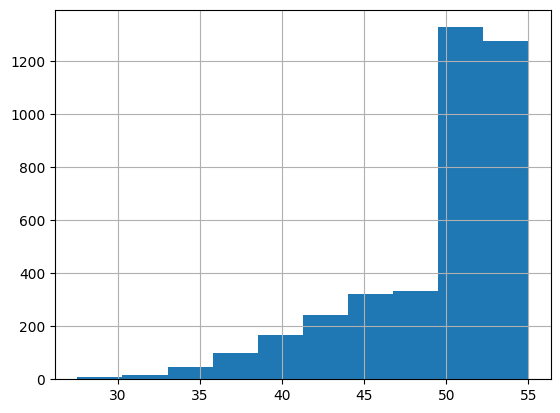

In [120]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)]['voix_pct'].hist()

In [121]:
fichier_vote_avec_code_postal_clean.to_csv("/home/onyxia/work/projet3A/data/donnees_electorales/donnees_muni_epci_completes.csv", index=False)

In [122]:
from functions import basic_functions 
#importlib.reload(BDTopo_fonctions)
#from BDTopo_fonctions import upload_to_onyxia
basic_functions.upload_to_onyxia(
    "/home/onyxia/work/projet3A/data/donnees_electorales/donnees_muni_epci_completes.csv",
    "mgarbe",
    "Elections/fichier_vote_avec_code_postal_clean.csv"
)

[Upload] Envoi de /home/onyxia/work/projet3A/data/donnees_electorales/donnees_muni_epci_completes.csv vers mgarbe/Elections/fichier_vote_avec_code_postal_clean.csv ...
[Upload] Terminé avec succès


In [123]:
duel_maires_toutes_annees = (donnees_muni_wide
                    .assign(annee = lambda d : d["id_election"].str[0:4])
                    .assign(dep = lambda d : d["ident_election_ville"].str[0:2]))


duel_maires = duel_maires_toutes_annees[(duel_maires_toutes_annees['annee']!= "2008")]
duel_maires_avec_comm = pd.merge(
                            duel_maires,
                            donnees_dep_avec_nuance_pour_muni,
                            how = 'left',
                            left_on = ['annee','ident_election_ville'],
                            right_on = ['annee','insee']
                            )

duel_maires_avec_comm.drop(inplace=True, columns = ['ident_election_ville','Région siège', 'Département siège', 'Arrondissement siège',
       'Commune siège', 'N° SIREN', 'Nom du groupement', 'Nature juridique',
       'Syndicat à la carte', 'Groupement interdépartemental',
       'Date de création', "Date d'effet", 'Mode de répartition des sièges',
       'Autre mode de répartition des sièges', 'Nombre de membres',
       'Population', 'Nombre de compétences exercées', 'Mode de financement',
       'Civilité Président', 'siren', 'siren_membre',"raison_sociale", "prenom", "nom"])

In [124]:
duel_maires_avec_comm_et_code_postal_wide = pd.merge(duel_maires_avec_comm,
                                        table_code_insee_code_postal,
                                        left_on = 'insee',
                                        right_on = 'Code INSEE',
                                        how = 'inner'
                                        )                             

In [129]:
duel_maires_avec_comm_et_code_postal_wide.to_csv("/home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_wide.csv", index=False)
basic_functions.upload_to_onyxia(
    "/home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_wide.csv",
    "mgarbe",
    "Elections/donnees_duel_maires_wide.csv"
)

[Upload] Envoi de /home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_wide.csv vers mgarbe/Elections/donnees_duel_maires_wide.csv ...
[Upload] Terminé avec succès


In [126]:
duel_maires_avec_comm_et_code_postal_wide_clean = duel_maires_avec_comm_et_code_postal_wide.rename(columns={"rang1_Prénom" : "prenom1",
"rang2_Prénom" : "prenom2", "rang1_Nom" : "Nom1", "rang2_Nom" : "Nom2", "rang1_Nuance" : "Nuance1", "rang2_Nuance" : "Nuance2", 
'rang1_voix_pct' : "voix_pct_1", 'rang2_voix_pct' : "voix_pct_2",
"Prénom Président" : "president_prenom", "Nom Président" : "president_nom"})
duel_maires_avec_comm_et_code_postal_wide_clean.columns

Index(['id_election', 'prenom1', 'prenom2', 'Nom1', 'Nom2', 'Nuance1',
       'Nuance2', 'voix_pct_1', 'voix_pct_2', 'election', 'tour', 'annee',
       'dep_x', 'president_prenom', 'president_nom', 'dep_y', 'Nuance_interco',
       'insee', 'dept', 'Code INSEE', 'Code Postal'],
      dtype='str')

In [127]:
duel_maires_avec_comm_et_code_postal_long = pd.wide_to_long(
    duel_maires_avec_comm_et_code_postal_wide_clean,
    stubnames=["Nom", "prenom","Nuance","voix_pct_"],
    i=['id_election','insee'],
    j="position"
).reset_index()

In [128]:
duel_maires_avec_comm_et_code_postal_long.to_csv("/home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_long.csv", index=False)

<Axes: ylabel='Frequency'>

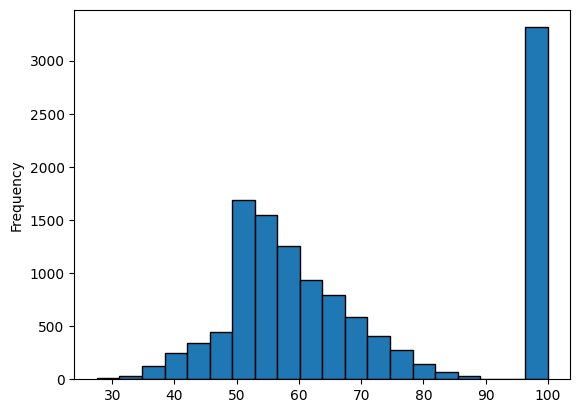

In [136]:
duel_maires_avec_comm_et_code_postal_wide_clean['voix_pct_1'].plot(kind='hist', bins=20, edgecolor='black')

In [137]:
duel_maires_avec_comm_et_code_postal_wide_clean.shape

(12263, 21)

In [139]:
duel_maires_avec_comm_et_code_postal_wide_clean[duel_maires_avec_comm_et_code_postal_wide_clean['annee'] == "2014"].shape

(9218, 21)

In [ ]:
duel_maires_avec_comm_et_code_postal_wide_clean[duel_maires_avec_comm_et_code_postal_wide_clean['annee'] == "2020"].shape

(3045, 21)

In [143]:
duel_maires_avec_comm_et_code_postal_wide_clean[duel_maires_avec_comm_et_code_postal_wide_clean['Code Postal'] == "78220"]

,id_election,prenom1,prenom2,Nom1,Nom2,Nuance1,Nuance2,voix_pct_1,voix_pct_2,election,...,annee,dep_x,president_prenom,president_nom,dep_y,Nuance_interco,insee,dept,Code INSEE,Code Postal
6586,2014_muni_t1,Olivier,Julien,LEBRUN,BOUFFARTIGUE,LUD,LSOC,60.498329,21.558797,2014_muni,...,2014,78,François,de mazieres,78,LDVD,78686,78,78686,78220
11021,2020_muni_t1,Olivier,Cécile,LEBRUN,CHOPARD,LDVD,LDVC,55.674044,22.354125,2020_muni,...,2020,78,François,de mazieres,78,LDVD,78686,78,78686,78220
